## **Import libraries**

In [ ]:
import os
import random

SEED = 8
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import pandas as pd

from natsort import natsorted
from collections import defaultdict

import torch
import torch.nn as nn
from transformers import set_seed as transformers_set_seed

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers_set_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

from SARVI.config import (
    paths
)
from SARVI.models.schemas import (
    PipelineContext,
    DOCXToJSONSConfig,
    LLMConfig
)
from SARVI.models.losses import (
    MoMLoss
)

from SARVI.data_io.reader import (
    textwrap,
    read_txt_list, read_ann_list,
    read_json_single,
    read_excel_single
)
from SARVI.data_io.writing import (
    write_torch_checkpoint, write_json_extra_docs, write_parquet
)

from SARVI.services.common.llm_loader import (
    load_llm
)
from SARVI.services.common.tree_funcs import (
    load_tree_hierarchical_module
)
from SARVI.services.common.llm_funcs import (
    prompts as prompts_total
)
from SARVI.services.common.ner_funcs import(
    tokenizer_ner, model_ner, initialize_bio_ner_model
)
from SARVI.services.common.icd_pred_funcs import(
    initialize_icd10_hs_head_model,
    initialize_icd10_hs_prediction_model,
    initialize_icd10_no_hs_head_model,
)
from SARVI.services.sync_funcs.ner_funcs import (
    prepare_data as prepare_data_SYNC,
    construct_loaders_ner as construct_loaders_ner_SYNC,
    run_bio_nerclassifier as run_bio_nerclassifier_SYNC
)

from SARVI.services.async_funcs.llm_funcs import (
    asyncio
)

Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[2026-05-27 16:43:15] INFO SentenceTransformer.py:219: Use pytorch device_name: cuda:0
[2026-05-27 16:43:15] INFO SentenceTransformer.py:227: Load pretrained SentenceTransformer: all-MiniLM-L6-v2


## **Initialize variables**

In [ ]:
def initialize_variables(ctx: PipelineContext):
    print("0. Initializing variables\n")
    # create_intermediate_folder_name(ctx)

    #################################################################################################################

    if ctx.cie_10_version == "2018":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2018.xlsx", sheet_name="finales", header=0)
        df_reference = df_reference[['codigo', 'descripcion']].reset_index(drop=True).rename(columns={'codigo': 'Código', 'descripcion': 'Descripción'})
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    elif ctx.cie_10_version == "2024":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2024.xlsx", sheet_name="ES2024 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    else:
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    #################################################################################################################

    report_list = natsorted(p for p in (ctx.paths.data_input / ctx.folder_and_archive_name).iterdir() if p.is_file())
    
    if ctx.ussage == "generative":
        llm = load_llm(ctx.llm_config)
        prompt = textwrap.dedent(prompts_total["report_to_data"])
        modelo_ner = None
        node_list = None
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        label2id_ICD10 = None
        id2label_ICD10 = None
        id_no_hs_to_id_hs = None
        icd10_thresholds = None
    else:
        llm = None
        prompt = None
        modelo_ner = [None, None]
        node_list = load_tree_hierarchical_module(df_reference)

        root = node_list["root"]
        root.set_indexes()
        label2id_hs = {key.name: value for key, value in root.node_to_id.items()}
        id2label_hs = {value: key for key, value in label2id_hs.items()}
        label2id_no_hs = {id2label_hs[value.item()]: i for i, value in enumerate(root.leaf_indexes)}
        id2label_no_hs = {value: key for key, value in label2id_no_hs.items()}
        label2id_ICD10 = [label2id_hs, label2id_no_hs]
        id2label_ICD10 = [id2label_hs, id2label_no_hs]
        id_no_hs_to_id_hs = {id_no_hs: label2id_hs[label_name] for label_name, id_no_hs in label2id_no_hs.items()}

        # modelo_icd10_head = [initialize_icd10_hs_head_model(ctx, "ICD10_HS_checkpoint.pt", root), initialize_icd10_no_hs_head_model(ctx, "ICD10_NO_HS_checkpoint.pt", label2id_no_hs, root)]
        # modelo_icd10_prediction = [initialize_icd10_hs_prediction_model(ctx, "ICD10_HS_checkpoint.pt", label2id_hs, root), None]
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        icd10_thresholds = read_json_single(ctx.paths.docs_dir / "thresholds_ICD10.json")
    
    semaforo = asyncio.Semaphore(ctx.MAX_CONCURRENCY)

    config = DOCXToJSONSConfig(
        report_list=report_list,
        prompt=prompt,
        llm=llm,
        semaforo=semaforo,
        modelo_ner=modelo_ner,
        node_list=node_list,
        modelo_icd10_head=modelo_icd10_head,
        modelo_icd10_prediction=modelo_icd10_prediction,
        label2id_ICD10=label2id_ICD10,
        id2label_ICD10=id2label_ICD10,
        id_no_hs_to_id_hs=id_no_hs_to_id_hs,
        icd10_thresholds=icd10_thresholds
    )

    return config

In [3]:
llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

ctx = PipelineContext(
    ussage="deterministic",
    folder_and_archive_name="CodiEsp/train",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

config = initialize_variables(ctx)

0. Initializing variables



Hierarchical tree construction: Cleaning data:   0%|          | 0/102426 [00:00<?, ?code/s]

## **Run BIO NER data creation**

### **Create data**

In [4]:
print("1.1. Creating NER data // Train data")
dict_data_train = read_txt_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_data_train = pd.DataFrame(list(dict_data_train.items()), columns=["archivo_origen", "Text"])

dict_ann_train = read_ann_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_ann_train = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_train.items()])
# df_ann = None

data_prepared_train, all_window_labels_train, file_names_train = prepare_data_SYNC(df_data_train, data_ann=df_ann_train, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

print("1.1. Creating NER data // Dev data")
dict_data_dev = read_txt_list(ctx.paths.data_input / "CodiEsp/dev")
df_data_dev = pd.DataFrame(list(dict_data_dev.items()), columns=["archivo_origen", "Text"])

dict_ann_dev = read_ann_list(ctx.paths.data_input / "CodiEsp/dev")
df_ann_dev = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_dev.items()])
# df_ann = None

data_prepared_dev, all_window_labels_dev, file_names_dev = prepare_data_SYNC(df_data_dev, data_ann=df_ann_dev, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

1.1. Creating NER data // Train data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/500 [00:00<?, ?te…

Token indices sequence length is longer than the specified maximum sequence length for this model (685 > 512). Running this sequence through the model will result in indexing errors


1.1. Creating NER data // Dev data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/250 [00:00<?, ?te…

> Example of label output

In [5]:
### Example of labels
example_window_labels = all_window_labels_train[2][0]
example_data_prepared = data_prepared_train[2][0]["input_ids"]

for i,(label,token) in enumerate(zip(example_window_labels,tokenizer_ner.convert_ids_to_tokens(example_data_prepared))):
    if label != "O":
        print(f"{label}: {token}")
        if i+1 <= len(example_window_labels) and example_window_labels[i+1] == "O":
            print()

1_B-DISO: ▁e
1_B-DISO: spon
1_B-DISO: dili
1_B-DISO: tis
1_I-DISO: ▁an
1_I-DISO: qui
1_I-DISO: los
1_I-DISO: ante

2_B-DISO;{3.1_B-DISO}: ▁quis
2_B-DISO;{3.1_B-DISO}: tes
2_I-DISO: ▁hep
2_I-DISO: áticos

{3.2_I-DISO}: ▁renal
{3.2_I-DISO}: es

{4.1_B-DISO}: ▁Ri
{4.1_B-DISO}: ñó
{4.1_B-DISO}: n

{4.2_I-DISO};5_B-DISO: ▁enfermedad
{4.2_I-DISO}: ▁poli
{4.2_I-DISO}: qu
{4.2_I-DISO}: ística

6_B-DISO: ▁protein
6_B-DISO: uria

7_B-DISO: ▁protein
7_B-DISO: uria

8_B-DISO: ▁pú
8_B-DISO: r
8_B-DISO: pura

9_B-DISO: ▁her
9_B-DISO: nia
9_I-DISO: ▁um
9_I-DISO: bili
9_I-DISO: cal

10_B-DISO: ▁quis
10_B-DISO: tes
10_I-DISO: ▁hep
10_I-DISO: áticos



> Total count of labels

In [6]:
labels_unique = defaultdict(int)
for i in [i for window in all_window_labels_train for sublist in window for i in sublist]:
    labels_unique[i] += 1


bio_order = {"B": 0, "I": 1, "O": 2}
ordered_data = defaultdict(labels_unique.default_factory, sorted(labels_unique.items(), key=lambda x:(x[0].split("-", 1)[1] if "-" in x[0] else x[0], bio_order.get(x[0].split("-", 1)[0], 99))))
ordered_data

defaultdict(int,
            {'8_B-DISO': 1035,
             '8_I-DISO': 685,
             '12_B-DISO': 889,
             '14_B-DISO': 929,
             '1_B-DISO': 785,
             '3_I-DISO': 601,
             '4_B-DISO': 867,
             '4_I-DISO': 632,
             '5_B-DISO': 911,
             '6_I-DISO': 641,
             '9_B-DISO': 1051,
             '9_I-DISO': 583,
             '10_B-DISO': 1029,
             '12_I-DISO': 569,
             '13_B-DISO': 918,
             '1_I-DISO': 683,
             '2_I-DISO': 631,
             '6_B-DISO': 979,
             '7_B-DISO': 1037,
             '10_I-DISO': 736,
             '2_B-DISO': 692,
             '3_B-DISO': 784,
             '5_I-DISO': 736,
             '11_I-DISO': 629,
             '13_I-DISO': 685,
             '15_B-DISO': 995,
             '16_B-DISO': 823,
             '17_B-DISO': 713,
             '18_B-DISO': 644,
             '18_I-DISO': 303,
             '19_B-DISO': 671,
             '19_I-DISO': 372,
    

### **Create DataLoaders and models**

In [7]:
class TokenCrossEntropyLoss(nn.Module):
    def __init__(self, weight=None, ignore_index=-100, reduction="mean"):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(
            weight=weight,
            ignore_index=ignore_index,
            reduction="none"
        )
        self.reduction = reduction
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        """
        logits:  (B, T, C)
        targets: (B, T)
        """
        B, T, C = logits.shape

        flat_logits = logits.reshape(-1, C)
        flat_targets = targets.reshape(-1)

        loss = self.ce(flat_logits, flat_targets)
        loss = loss.view(B, T)

        if self.reduction == "none":
            return loss

        valid_mask = targets != self.ignore_index
        loss = loss * valid_mask

        if self.reduction == "sum":
            return loss.sum()

        return loss.sum() / valid_mask.sum().clamp(min=1)

In [ ]:
seed_everything(SEED)

dataset_full_train, data_loader_full_train, label2id, id2label = construct_loaders_ner_SYNC(data_prepared_train, all_window_labels_train, file_names_train, ner_type="bio", seed=SEED, ignore_o_labels=True, batch_size=4)
dataset_full_dev, data_loader_full_dev, _, _ = construct_loaders_ner_SYNC(data_prepared_dev, all_window_labels_dev, file_names_dev, ner_type="bio", label2id=label2id, id2label=id2label, seed=SEED, ignore_o_labels=True, batch_size=4)

config.modelo_ner[1] = initialize_bio_ner_model(ctx, model_ner, len(id2label), None)

ignore_index = -100
class_counts = torch.zeros(len(label2id))
for batch in data_loader_full_train:
    labels = batch["window_labels"].view(-1)
    valid_labels = labels[labels != ignore_index]
    class_counts += torch.bincount(valid_labels, minlength=len(label2id)).float()
class_counts = class_counts.to(ctx.device)
present = class_counts > 0
weights = torch.zeros_like(class_counts, device=ctx.device)
weights[present] = 1.0 / class_counts[present]
weights[present] = weights[present] / weights[present].sum() * present.sum()

optimizer = torch.optim.AdamW(config.modelo_ner[1].parameters(), lr=1e-5, weight_decay=0.001)
# criterion = MoMLoss(M=512, majority_label=label2id["O"], delta=0.05,
#                     # sentence_loss_fn=DiceLoss(epsilon=1.0, delta=0.01), 
#                     sentence_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
#                     majority_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
#                     ignore_index=ignore_index)
criterion = TokenCrossEntropyLoss(reduction="mean", weight=weights, ignore_index=ignore_index)

### **Train model**

In [ ]:
seed_everything(SEED)

print("1.2. Running NER model // BIO")
results = run_bio_nerclassifier_SYNC(config.modelo_ner[1], data_loader=data_loader_full_train, device=ctx.device, id2label=id2label, train=True, dev_data_loader=data_loader_full_dev, optimizer=optimizer, criterion=criterion, epochs=25, patience=5, ignore_index=ignore_index, return_predictions=False, return_probabilities=False, ignore_o_labels=True)

write_torch_checkpoint(ctx=ctx, name="NERTraining/BIO/CodiEsp/bio_nerclassifier_checkpoint", checkpoint=results["best_model_state"])
write_parquet(ctx=ctx, name="NERTraining/BIO/CodiEsp/bio_nerclassifier_results", data=pd.DataFrame([{k: (v.tolist() if hasattr(v, "tolist") else v) for k, v in results.items() if k != "best_model_state"}]))
write_json_extra_docs(ctx=ctx, file_name="NERTraining/BIO/CodiEsp/id2label_bio_nerclassifier", content=id2label)
write_json_extra_docs(ctx=ctx, file_name="NERTraining/BIO/CodiEsp/label2id_bio_nerclassifier", content=label2id)

1.2. Running NER model // BIO


BIO NER / Training:   0%|          | 0/25 [00:00<?, ?epoch/s]

BIO NER / Training epoch 1 / Train set:   0%|          | 0/125 [00:00<?, ?batch/s]

BIO NER / Training epoch 1 / Dev set:   0%|          | 0/63 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.8534    0.8770    0.8650     13769

   micro avg     0.8534    0.8770    0.8650     13769
   macro avg     0.8534    0.8770    0.8650     13769
weighted avg     0.8534    0.8770    0.8650     13769

Epoch 1/25 | train loss: 0.335405 | dev loss: 0.223406 | Best F1 (macro): 0.8650


...

BIO NER / Training epoch 6 / Dev set:   0%|          | 0/63 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.8665    0.8717    0.8691     13769

   micro avg     0.8665    0.8717    0.8691     13769
   macro avg     0.8665    0.8717    0.8691     13769
weighted avg     0.8665    0.8717    0.8691     13769

Epoch 6/25 | train loss: 0.056331 | dev loss: 0.272821 | Best F1 (macro): 0.8817


BIO NER / Training epoch 7 / Train set:   0%|          | 0/125 [00:00<?, ?batch/s]

BIO NER / Training epoch 7 / Dev set:   0%|          | 0/63 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

        DISO     0.8808    0.8623    0.8714     13769

   micro avg     0.8808    0.8623    0.8714     13769
   macro avg     0.8808    0.8623    0.8714     13769
weighted avg     0.8808    0.8623    0.8714     13769


Early stopping at epoch 7 | Best epoch: 2 | Best dev macro F1: 0.881678


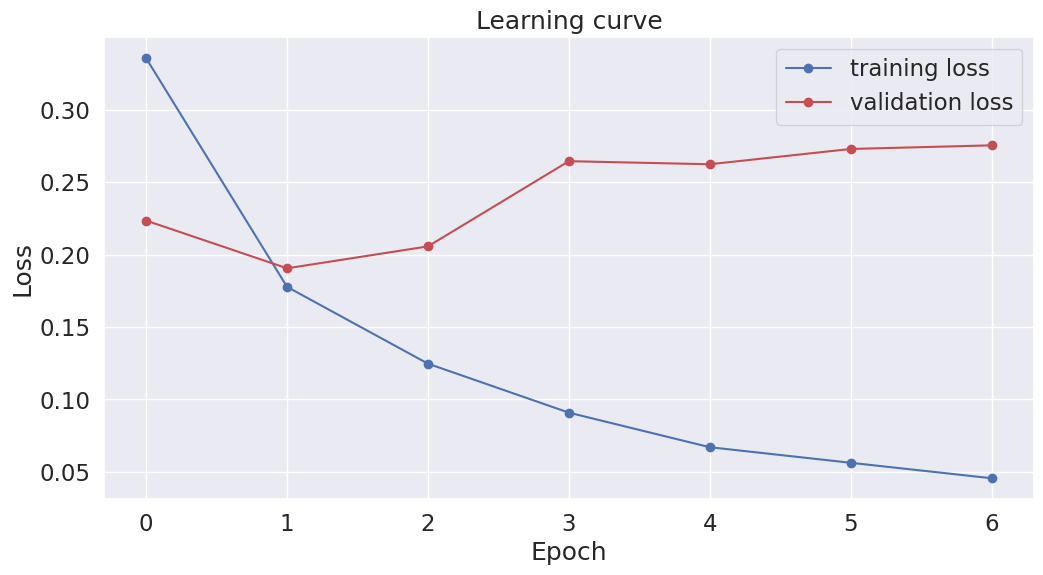

In [10]:
# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(results["loss_values"], 'b-o', label="training loss")
plt.plot(results["development_loss_values"], 'r-o', label="validation loss")

# Label the plot.
plt.title("Learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

### **Eval model**

In [11]:
print("1.1. Creating NER data // Test data")
# dict_data_test = read_txt_list(ctx.paths.data_input / "CodiEsp/test")
dict_data_test = read_txt_list(ctx.paths.data_input / "CodiEsp/test")
df_data_test = pd.DataFrame(list(dict_data_test.items()), columns=["archivo_origen", "Text"])

# dict_ann_test = read_ann_list(ctx.paths.data_input / "CodiEsp/test")
dict_ann_test = read_ann_list(ctx.paths.data_input / "CodiEsp/test")
df_ann_test = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test.items()])
# df_ann = None

data_prepared_test, all_window_labels_test, file_names_test = prepare_data_SYNC(df_data_test, data_ann=df_ann_test, padding=True, tokenizer=tokenizer_ner, model=model_ner, device=ctx.device)

1.1. Creating NER data // Test data


Preparing data for NER prediction: Window slicing and overlapping tokens:   0%|          | 0/250 [00:00<?, ?te…

In [12]:
id2label = read_json_single(ctx.paths.docs_dir / "NERTraining/BIO/CodiEsp/id2label_bio_nerclassifier.json")
label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/BIO/CodiEsp/label2id_bio_nerclassifier.json")
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: int(k)  for k, v in id2label.items()}
dataset_full_test, data_loader_full_test, _, _ = construct_loaders_ner_SYNC(data_prepared_test, all_window_labels_test, file_names_test, ner_type="bio", label2id=label2id, id2label=id2label, seed=SEED)

config.modelo_ner[1] = initialize_bio_ner_model(ctx, model_ner, len(id2label), "NERTraining/BIO/CodiEsp/bio_nerclassifier_checkpoint.pt")

In [13]:
results = run_bio_nerclassifier_SYNC(config.modelo_ner[1], data_loader=data_loader_full_test, device=ctx.device, id2label=id2label, train=False, return_predictions=True, return_probabilities=False)

BIO NER / Inference:   0%|          | 0/32 [00:00<?, ?batch/s]


Classification report:
              precision    recall  f1-score   support

        DISO     0.0612    0.6080    0.1111     14430

   micro avg     0.0612    0.6080    0.1111     14430
   macro avg     0.0612    0.6080    0.1111     14430
weighted avg     0.0612    0.6080    0.1111     14430



## **Results to .ann format**

In [ ]:
from SARVI.services.common.utils.ann_utils import ner_outputs_to_ann
from SARVI.data_io.writing import write_ann_list

In [15]:
ann_format = ner_outputs_to_ann(results, id2label, data_loader=data_loader_full_test, original_texts=df_data_test, tokenizer=tokenizer_ner)
# write_ann_list(ctx, ann_format, ctx.paths.data_intermediate / ctx.folder_and_archive_name / "bio")
write_ann_list(ctx, ann_format, ctx.paths.data_intermediate / "CodiEsp/test" / "bio")

## **NER results**

In [16]:
from SARVI.services.common.ner_funcs import classification_report_ner

In [17]:
# dict_ann_test_true = read_ann_list(ctx.paths.data_input / "CodiEsp/test")
dict_ann_test_true = read_ann_list(ctx.paths.data_input / "CodiEsp/test")
df_ann_test_true = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test_true.items()])

# dict_ann_test_pred = read_ann_list(ctx.paths.data_intermediate / ctx.folder_and_archive_name / "bio")
dict_ann_test_pred = read_ann_list(ctx.paths.data_intermediate / "CodiEsp/test" / "bio")
df_ann_test_pred = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test_pred.items()])

label2id = read_json_single(ctx.paths.docs_dir / "NERTraining/Span/label2id_span_nerclassifier.json")

In [18]:
results = classification_report_ner(df_ann_test_true, df_ann_test_pred, [k for k in label2id.keys() if k != "O"])

              precision    recall  f1-score   support   type_1   type_2   type_3   type_4   type_5

        LIVB     0.0000    0.0000    0.0000         0        0        0        0        0        0
        Date     0.0000    0.0000    0.0000         0        0        0        0        0        0
    Spec_cue     0.0000    0.0000    0.0000         0        0        0        0        0        0
     Neg_cue     0.0000    0.0000    0.0000         0        0        0        0        0        0
        DISO     0.0284    0.3585    0.0526      3665    42670        0        0        0     2351

   micro avg     0.0284    0.3585    0.0526      3665    42670        0        0        0     2351
   macro avg     0.0057    0.0717    0.0105      3665    42670        0        0        0     2351
weighted avg     0.0284    0.3585    0.0526      3665    42670        0        0        0     2351
